In [ ]:
# class PIDController:
#     def __init__(self, kp, ki, kd, setpoint):
#         self.kp = kp
#         self.ki = ki
#         self.kd = kd
#         self.setpoint = setpoint
#         self.previous_error = 0
#         self.integral = 0

#     def compute(self, measurement, dt):
#         error = self.setpoint - measurement
#         self.integral += error * dt
#         derivative = (error - self.previous_error) / dt

#         output = (self.kp * error) + (self.ki * self.integral) + (self.kd * derivative)
#         self.previous_error = error
#         return output

# # PID 제어기 초기화
# pid = PIDController(kp=1.0, ki=0.1, kd=0.01, setpoint=10.0)

# # 제어 값 계산
# measurement = 8.0  # 현재 측정 값
# dt = 0.1  # 샘플링 시간
# control_signal = pid.compute(measurement, dt)
# print(f"Control Signal: {control_signal}")

In [1]:
from pymycobot import MyCobot280
import time

mc = MyCobot280("/dev/ttyJETCOBOT", 1000000)

# memory address
POS_PROPORTIONAL_GAIN    = 0x15; #21
POS_INTEGRAL_GAIN        = 0x17; #23
POS_DERIVATIVE_GAIN      = 0x16; #22

In [2]:
data_id = POS_INTEGRAL_GAIN ## 수정
time_sleep = 0.1

p_value = [25, 42, 40, 34, 32, 25]  
i_value = [2] * 6
d_value = [20, 11, 10, 28, 25, 25]

for i in range(6):
    mc.set_servo_data(i+1,data_id,i_value[i]) ## 수정
    time.sleep(time_sleep)

for i in range(6):
    time.sleep(time_sleep)
    print(mc.get_servo_data(i+1,data_id))

2
2
2
2
2
2


In [ ]:
# p_value = [25, 42, 40, 34, 32, 25]  
# i_value = [4]*6
# d_value = [20, 11, 8, 25, 25, 25]

# data_id = POS_PROPORTIONAL_GAIN ## 수정
# data_value = p_value

# num = 2 # 몇번 joint 움직일건지 
# time_sleep = 0.1


# mc.set_servo_data(num, data_id, data_value) ## num번 joint 값 수정
# time.sleep(time_sleep)


# for i in range(6):
#     time.sleep(time_sleep)
#     print(mc.get_servo_data(i+1,data_id))

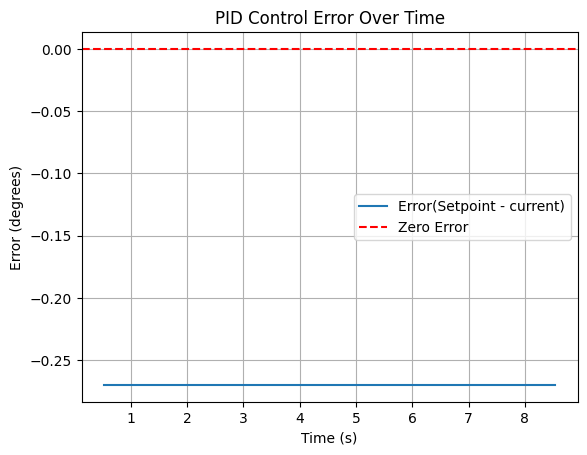

In [72]:
import time
import matplotlib.pyplot as plt
from pymycobot import MyCobot280  # 또는 사용중인 모델에 따라 수정

mc = MyCobot280("/dev/ttyJETCOBOT", 1000000)

errors = []
timestamps = []

# 1번 서보를 90도로 보낸 상황에서 오차 기록 예제
setpoint = -90 # 목표 각도
num = 4 # 몇번 joint 움직일건지 

setpoint_angles = [0, 0, 0, 0, 0, 0]  # 1번 서보만 90도, 나머지는 기본값
setpoint_angles[num] = setpoint
mc.send_angles(setpoint_angles, 100, _async=True)  # 1번 서보만 90도, 나머지는 기본값

start_time = time.time()

for i in range(70):
    angles = mc.get_angles()
    current = angles[num]  # 1번 서보
    error = setpoint - current

    errors.append(error)
    timestamps.append(time.time() - start_time)

    # print(f"t={timestamps[-1]:.2f}s, error={error:.2f}")
    time.sleep(0.1)

# 그래프 그리기
plt.plot(timestamps, errors, label='Error(Setpoint - current)')
plt.axhline(0, color='r', linestyle='--', label='Zero Error')
plt.xlabel('Time (s)')
plt.ylabel('Error (degrees)')
plt.title('PID Control Error Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
errors

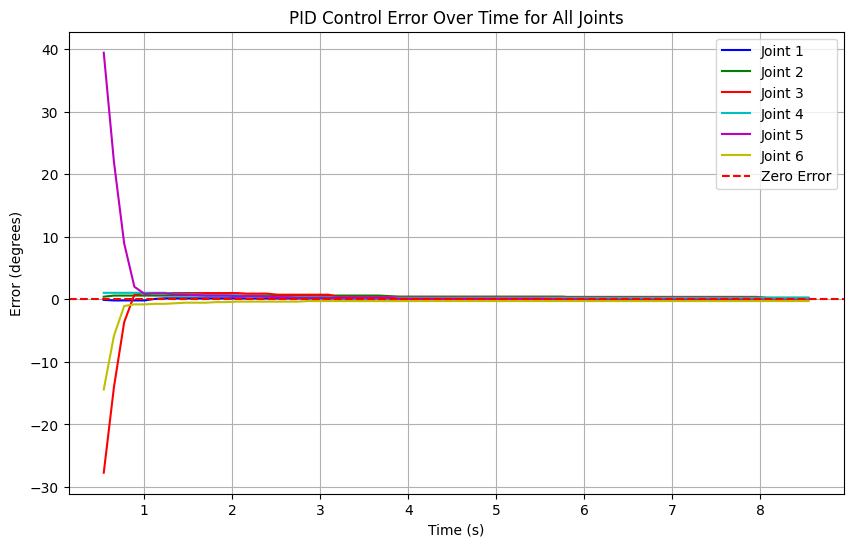

In [73]:
setpoint_angles = [0.0, 0.0, -70.0, 0.0, 0.0, -45.0]

import time
import matplotlib.pyplot as plt
from pymycobot import MyCobot280  # 사용 환경에 따라 수정

mc = MyCobot280("/dev/ttyJETCOBOT", 1000000)

num_joints = 6
setpoint_angles = [0.0, 0.0, -70.0, 0.0, 0.0, -45.0]

# 목표 각도를 한 번에 보내기
mc.send_angles(setpoint_angles, 100, _async=True)

errors = [[] for _ in range(num_joints)]
timestamps = []

start_time = time.time()

# 약 7초간(70회 * 0.1초) 측정
for _ in range(70):
    angles = mc.get_angles()
    current_time = time.time() - start_time
    timestamps.append(current_time)
    
    for i in range(num_joints):
        error = setpoint_angles[i] - angles[i]
        errors[i].append(error)
    
    time.sleep(0.1)

# 색상 및 그래프 그리기
colors = ['b', 'g', 'r', 'c', 'm', 'y']

plt.figure(figsize=(10, 6))
for i in range(num_joints):
    plt.plot(timestamps, errors[i], label=f'Joint {i+1}', color=colors[i])

plt.axhline(0, color='r', linestyle='--', label='Zero Error')
plt.xlabel('Time (s)')
plt.ylabel('Error (degrees)')
plt.title('PID Control Error Over Time for All Joints')
plt.legend()
plt.grid(True)
plt.show()



In [83]:
errors[3]

[1.05,
 1.05,
 1.05,
 1.05,
 1.05,
 1.05,
 1.05,
 0.87,
 0.87,
 0.79,
 0.7,
 0.7,
 0.7,
 0.7,
 0.43,
 0.43,
 0.43,
 0.35,
 0.35,
 0.35,
 0.35,
 0.35,
 0.35,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26,
 0.26]